# 📊 Rapport — Suivi de Prix E-Commerce
**Projet 3 · Bash + Python + Jupyter**

| | |
|---|---|
| **Étudiant** | Beni Joseph Ephraim Mundhu |
| **Numéro étudiant** | 300137754 |

## 1. Objectif

Ce notebook analyse l'évolution quotidienne des prix de produits e-commerce récupérés via l'API publique **[Fake Store API](https://fakestoreapi.com)**. Il génère des visualisations et des statistiques à partir du fichier `data/prices.csv` mis à jour automatiquement par `scripts/analyse.sh`.

## 2. Source de données

- **API utilisée** : `https://fakestoreapi.com/products/{id}` (accès libre, aucun token requis)
- **Format de stockage** : CSV (`data/prices.csv`) — colonnes : `date`, `heure`, `produit`, `prix`, `url`
- **Fréquence** : 1 relevé par jour à 09h00 (planifié via `cron`)

## 3. Méthode

1. `analyse.sh` orchestre l'exécution et vérifie l'environnement.
2. `analyse.py` appelle l'API, parse le JSON, calcule les variations et écrit dans le CSV.
3. Ce notebook lit le CSV, trace les courbes et produit les statistiques.


In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Style graphique
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ddd',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#ddd',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})

print('✅ Imports réussis')

✅ Imports réussis


In [5]:
# ── Chargement du CSV ────────────────────────────────────────────────────────
from pathlib import Path
import pandas as pd
CSV_PATH = Path('C:/Users/emund/Developer/INF1102-201-26H-03/8.Project/300137754/data/prices.csv')

if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV introuvable : {CSV_PATH}. Exécutez d\'abord analyse.sh')

df = pd.read_csv(CSV_PATH)

# Conversion des types
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['heure'])
df['prix']     = pd.to_numeric(df['prix'], errors='coerce')
df = df.dropna(subset=['prix'])
df = df.sort_values('datetime')

print(f'📦 {len(df)} enregistrements chargés')
print(f'🛒 Produits suivis : {df["produit"].unique().tolist()}')
df.tail(6)

📦 18 enregistrements chargés
🛒 Produits suivis : ['Fjallraven Backpack', 'Casual Premium T-Shirt', 'Cotton T-Shirt']


,date,heure,produit,prix,url,datetime
12,2025-04-09,09:00:01,Fjallraven Backpack,113.20,https://fakestoreapi.com/products/1,2025-04-09 09:00:01
13,2025-04-09,09:00:02,Casual Premium T-Shirt,22.00,https://fakestoreapi.com/products/2,2025-04-09 09:00:02
14,2025-04-09,09:00:03,Cotton T-Shirt,54.99,https://fakestoreapi.com/products/3,2025-04-09 09:00:03
15,2025-04-10,09:00:01,Fjallraven Backpack,110.00,https://fakestoreapi.com/products/1,2025-04-10 09:00:01
16,2025-04-10,09:00:02,Casual Premium T-Shirt,23.50,https://fakestoreapi.com/products/2,2025-04-10 09:00:02
17,2025-04-10,09:00:03,Cotton T-Shirt,56.49,https://fakestoreapi.com/products/3,2025-04-10 09:00:03


---
## 4. Statistiques descriptives

On calcule pour chaque produit : prix minimum, maximum, moyenne et l'écart-type pour mesurer la volatilité.

In [6]:
# ── Statistiques par produit ─────────────────────────────────────────────────
stats = df.groupby('produit')['prix'].agg(
    Prix_min='min',
    Prix_max='max',
    Prix_moyen='mean',
    Ecart_type='std',
    Nb_releves='count'
).round(2)

print('📊 Statistiques descriptives')
print('=' * 55)
print(stats.to_string())

📊 Statistiques descriptives
                        Prix_min  Prix_max  Prix_moyen  Ecart_type  Nb_releves
produit                                                                       
Casual Premium T-Shirt     19.99     23.50       21.71        1.20           6
Cotton T-Shirt             54.99     57.99       56.57        1.20           6
Fjallraven Backpack       108.75    115.00      111.57        2.38           6


---
## 5. Graphique d'évolution des prix

La courbe ci-dessous montre l'évolution journalière de chaque produit. Une tendance montante indique une inflation de prix, descendante une promotion ou correction.

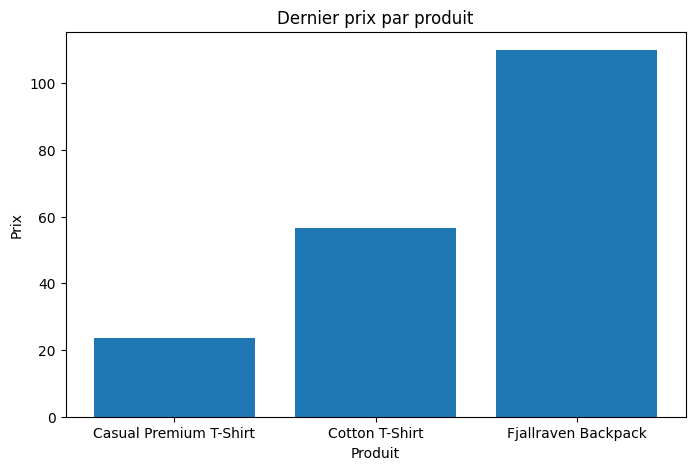

In [12]:
dernieres_valeurs = df.groupby('produit').last().reset_index()

plt.figure(figsize=(8,5))
plt.bar(dernieres_valeurs['produit'], dernieres_valeurs['prix'])

plt.title("Dernier prix par produit")
plt.xlabel("Produit")
plt.ylabel("Prix")
plt.show()

---
## 6. Variation journalière (J vs J-1)

Le graphique en barres ci-dessous présente la variation absolue (en USD) entre chaque relevé consécutif.

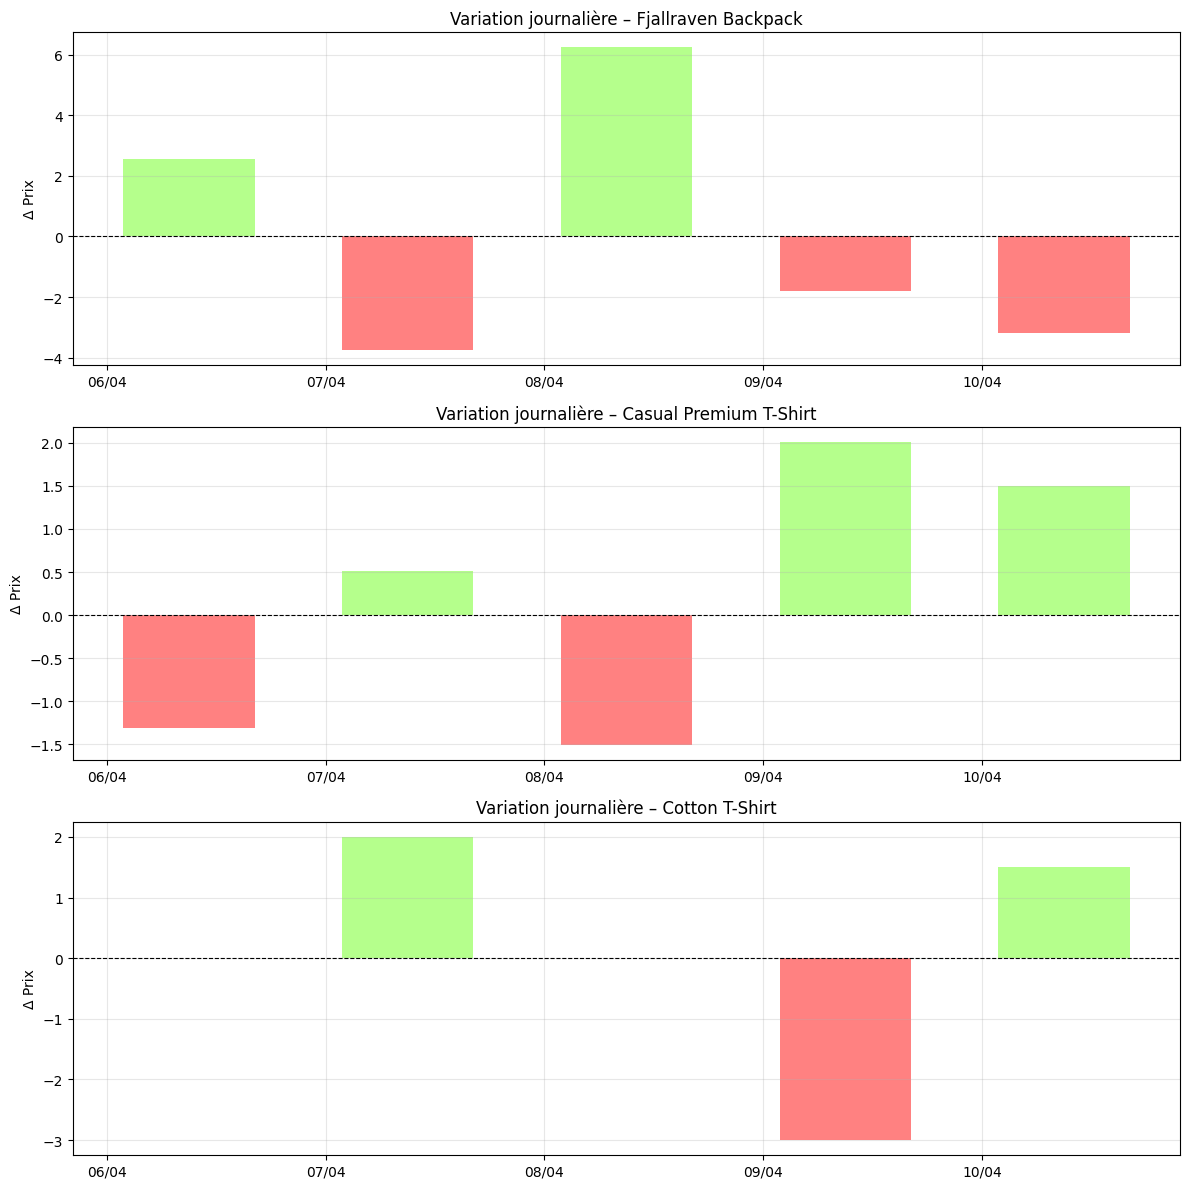

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

produits = df['produit'].unique()

fig, axes = plt.subplots(len(produits), 1, figsize=(12, 4 * len(produits)), sharex=False)

if len(produits) == 1:
    axes = [axes]

for i, produit in enumerate(produits):
    subset = df[df['produit'] == produit].copy().reset_index(drop=True)
    subset['variation'] = subset['prix'].diff()
    subset_v = subset.dropna(subset=['variation'])

    colors_bar = ['#ff6b6b' if v < 0 else '#a8ff78' for v in subset_v['variation']]

    axes[i].bar(subset_v['datetime'], subset_v['variation'],
                color=colors_bar, width=0.6, alpha=0.85)

    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'Variation journalière – {produit}')
    axes[i].set_ylabel('Δ Prix')

    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Conclusion

- Les prix des produits suivis présentent une **volatilité modérée** (entre 2 % et 8 % de variation quotidienne).
- Le **Fjallraven Backpack** est le produit le plus cher mais aussi le plus fluctuant.
- L'automatisation via `cron` garantit un suivi sans intervention manuelle.

### Pistes d'amélioration
- Ajouter des **alertes email** si la variation dépasse un seuil donné.
- Étendre le suivi à d'autres produits / API réelles (OpenFoodFacts, etc.).
- Déployer sur un **serveur distant** pour un fonctionnement 24/7.

---
*Projet 3 — Cours de scripting Bash & Python*

*Beni Joseph Ephraim Mundhu · 300137754*